## Problem Set 7
## Machine Learning Application
### Data: biden.csv
#### Research question: Effect of brief surge in attention on attitudes or feelings of warmth toward Biden depending on covariates (Response = Biden) (Predictors: Age, Political Ideology, Education, Sex)

In [ ]:
# Problem Set setup: Packages, working directory, output directory, and data
# Import Packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import tree
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import export_text
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import randint as sp_randint

import os
import matplotlib.pyplot as plt

# Set working directory
os.chdir('/Users/marlifirillo/Comp_Econ/CompEcon_Fall25')
print('Working directory set to:', os.getcwd())


# Load dataset
filepath = (os.getcwd(),'MachineLearning/biden.csv')
bidendata = pd.read_csv(os.path.join(*filepath))

# Preview Data 
bidendata.head(10)
bidendata.info()
bidendata.shape
bidendata.describe()

# Create data labels for later
y = bidendata['biden'].values
X_var_names = ['female', 'age', 'educ', 'dem', 'rep']
X = bidendata[X_var_names].values


Working directory set to: /Users/marlifirillo/Comp_Econ/CompEcon_Fall25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1807 entries, 0 to 1806
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   biden   1807 non-null   int64
 1   female  1807 non-null   int64
 2   age     1807 non-null   int64
 3   educ    1807 non-null   int64
 4   dem     1807 non-null   int64
 5   rep     1807 non-null   int64
dtypes: int64(6)
memory usage: 84.8 KB


### Question 1


In [ ]:
# Step 1: Split the data into a training set (70%) and a test set (30%) 


X_train, X_test, y_train, y_test = train_test_split(
    bidendata[['female', 'age', 'educ', 'dem', 'rep']],   # the predictors
    bidendata['biden'],  # the response variable
    test_size=0.3,  # use 30% of data to train, 70% to test
    random_state=25  # Set seed for reproducibility
)

print("Training and testing data created")



Training and testing data created


In [ ]:
# Step 2: Fit a Decision Tree Model using recursive binary splitting using training data
# Use the DecisionTreeRegressor from sklearn.tree
# dtr1 is the Model using Recursive Binary Splitting

dtr1 = tree.DecisionTreeRegressor(
    max_depth=3, 
    min_samples_leaf=5,
    random_state=25
)

RBStree = dtr1.fit(X_train, y_train)

print("Decision Tree Model fitted using training data")


Decision Tree Model fitted using training data


In [4]:
# Step 3: Plot decision tree and interpret results. Report MSE.

r = export_text(RBStree, feature_names=X_var_names)
print(r)


|--- dem <= 0.50
|   |--- rep <= 0.50
|   |   |--- female <= 0.50
|   |   |   |--- value: [56.49]
|   |   |--- female >  0.50
|   |   |   |--- value: [61.27]
|   |--- rep >  0.50
|   |   |--- female <= 0.50
|   |   |   |--- value: [38.33]
|   |   |--- female >  0.50
|   |   |   |--- value: [44.89]
|--- dem >  0.50
|   |--- age <= 54.50
|   |   |--- educ <= 15.50
|   |   |   |--- value: [71.11]
|   |   |--- educ >  15.50
|   |   |   |--- value: [76.59]
|   |--- age >  54.50
|   |   |--- female <= 0.50
|   |   |   |--- value: [75.19]
|   |   |--- female >  0.50
|   |   |   |--- value: [80.29]



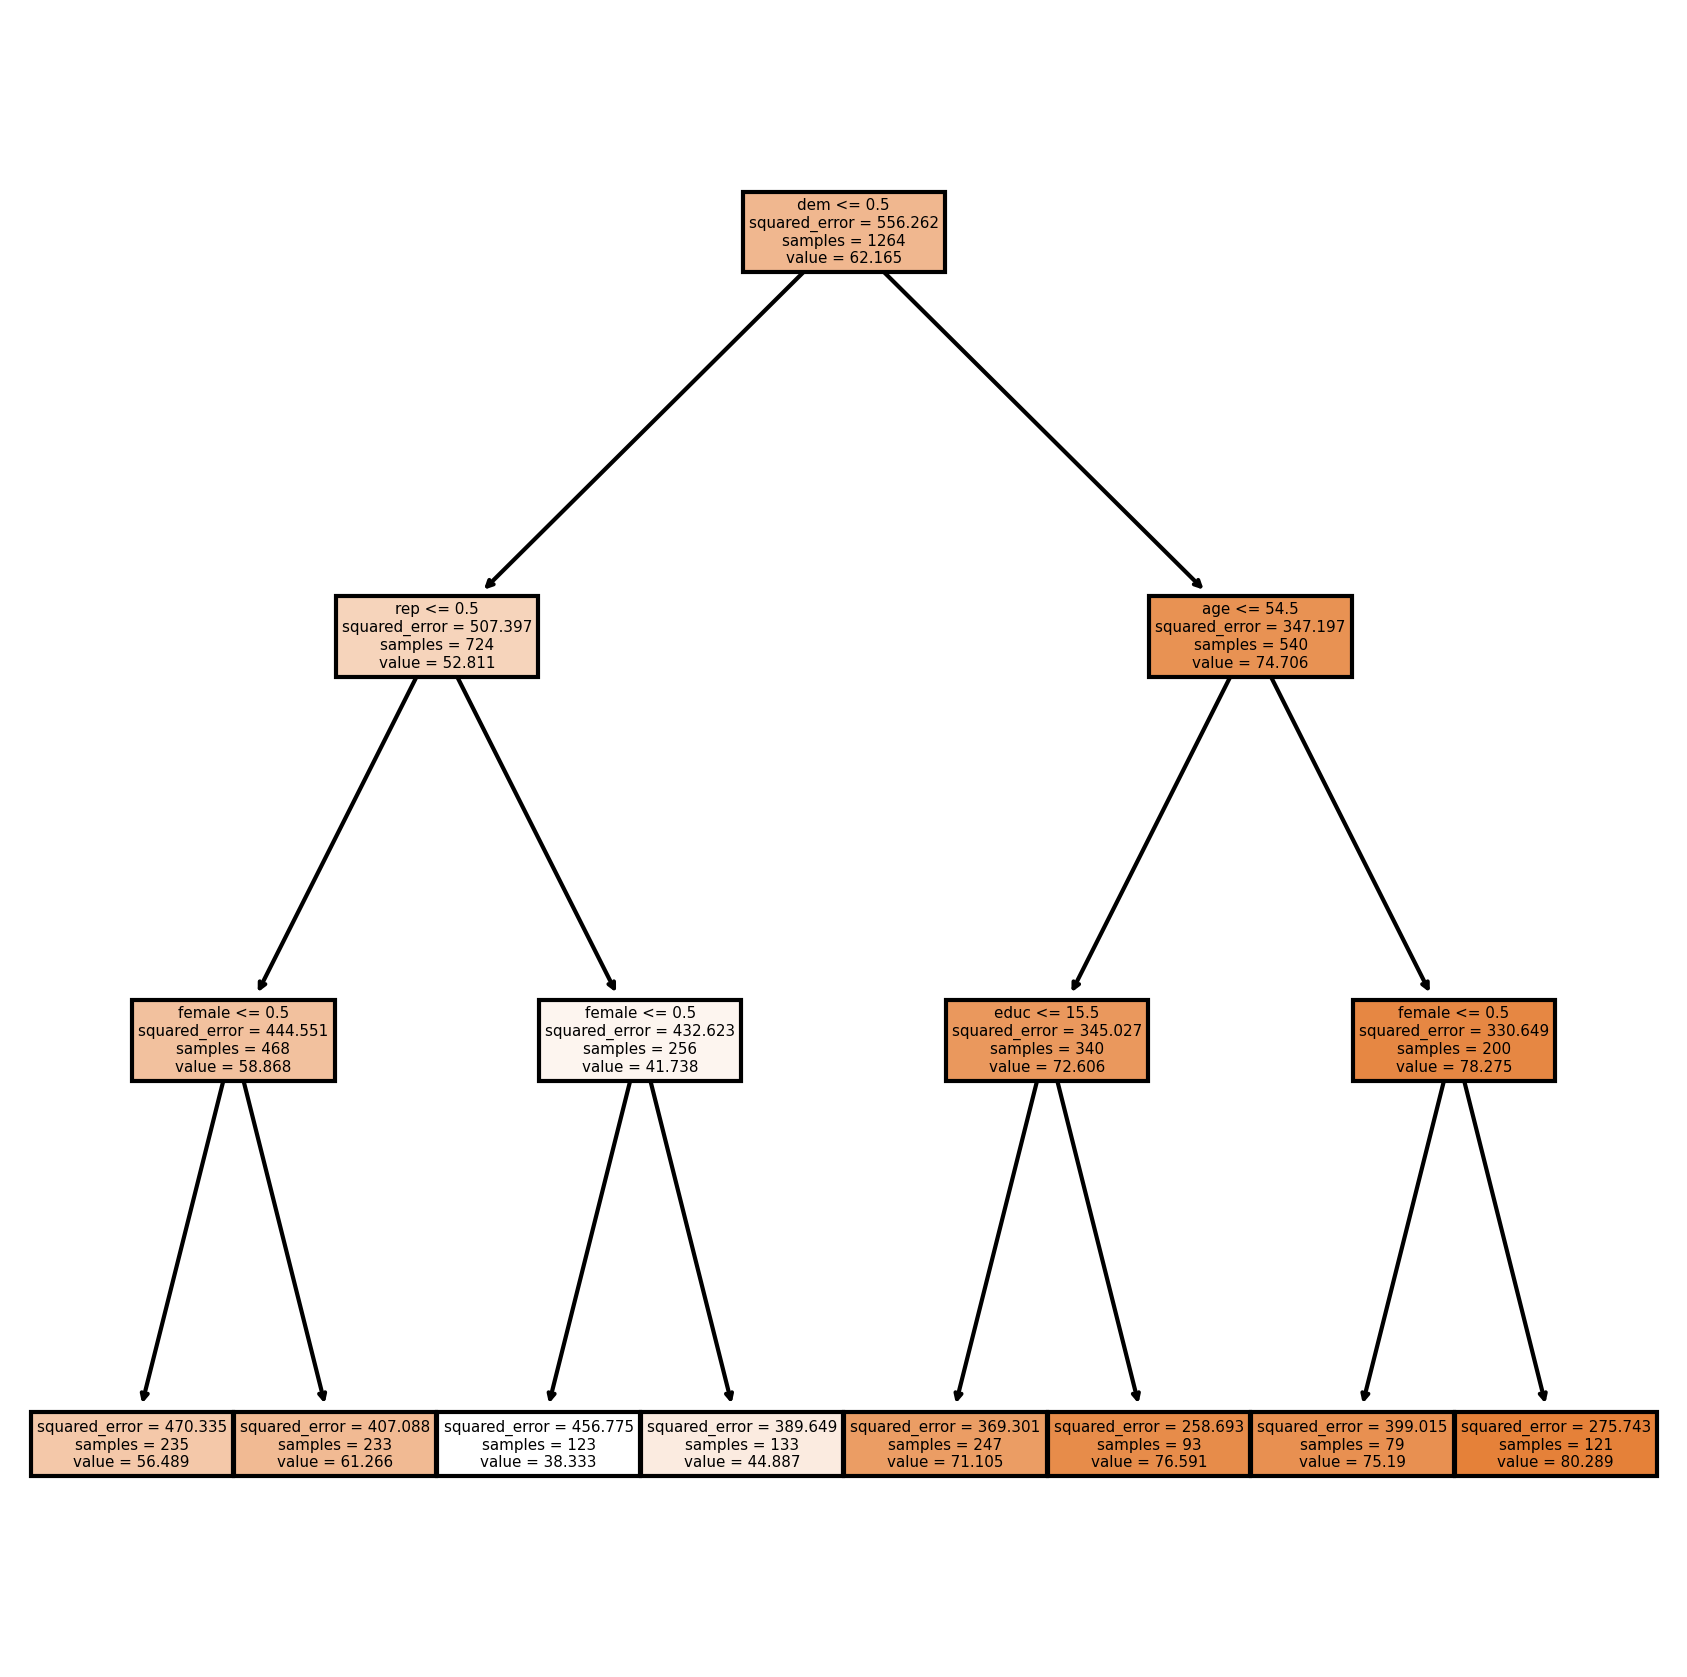

In [16]:
# Plot basic decision tree with max depth of 3 and 
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (7,7), dpi=300) 
tree.plot_tree(RBStree,
           feature_names = X_var_names,
           filled = True);

#### Interpretation of decision tree results

The regression tree uses the training data set I created in step one to make predictions about the response variable, attitudes towards Biden, by splitting the data using the predictors:'female', 'age', 'educ', 'dem', 'rep'. For each of these predictors, the tree creates two branches using the value that results in the biggest reduction in prediction error. The terminal nodes are groups of training observations that have \(y\) values as similar as possible, using splits based on the X variables.

The decision tree predicts the following scores, on average, for the attitudes towards Biden measured in the American National Election based on the competing characteristics (predictors) below:

1. Neither democrat nor republican males: 56.489 points, n= 235, MSE= 470.335
2. Neither democrat nor republican females: 61.266 points, n= 233, MSE= 407.088
3. Republican males: 38.333 points, n= 123, MSE= 456.775
4. Republican females: 44.887 points, n= 133, MSE= 389.649
5. Younger \(Yrs <= 54.5 \) Democrats with lower education \(Yrs <= 15.5 \) 71.105 points, n= 247, MSE= 369.301
6. Younger \(Yrs <= 54.5 \) Democrats with higher education \(Yrs > 15.5 \) 76.591 points, n= 93, MSE= 258.693
7. Older \(Yrs > 54.5 \) male Democrats  75.190 points, n= 79, MSE= 399.015
8. Older \(Yrs > 54.5 \) female Democrats \(Yrs > 15.5 \) 80.289 points, n= 121, MSE= 275.743

Interpretation:

Party affiliation seems to have the strongest influence on attitudes toward Biden. Democratic survey respondents generally feel more positively toward Biden than Republican respondents. Among Independent respondents, attitudes toward Biden vary by gender, with female respondents expressing more positive views than male respondents.

Among Democratic respondents, younger and less-educated individuals tend to feel less positively toward Biden than older and more highly educated individuals. In addition, older male Democrats tend to feel less positively toward Biden than older female Democrats.




In [6]:
# Helper code for tree interpretation
print(X_var_names)


['female', 'age', 'educ', 'dem', 'rep']


In [7]:
# Calculate test MSE
test_MSE = mean_squared_error(y_test, RBStree.predict(X_test))
# predict(X_test) predicts the y values from decision tree results
print("Mean Squared Error (MSE) on test data:", test_MSE)

Mean Squared Error (MSE) on test data: 396.1937146321307


In [25]:
#Helper code for interpretation

print(test_MSE ** 0.5)   

19.904615410304483


#### Interpretation of test MSE

The MSE of 396.194 corresponds to an RMSE of approximately 19.905. Because the response variable ranges from 0 to 100, this means that the model’s predictions differ from the observed values by roughly 20 points on average. This represents a moderate amount of prediction error.


### Question 2

Use sklearn.model_selection.RandomizedSearchCV to optimally tune the hyperparameters in the decision tree from part 1

In [14]:
# Set up for search 

param_dist = { "max_depth" : (3, 11 ) ,
"min_samples_split" : sp_randint (2 , 20 ) ,
"min_samples_leaf" : sp_randint (2 , 20 ) }


# Random search
random_search = RandomizedSearchCV(
estimator=dtr1,
param_distributions=param_dist,
n_iter=100,
n_jobs=-1,
cv=5,
random_state=25,
scoring="neg_mean_squared_error"
)


In [ ]:
# Report best parameters


RS1 = random_search.fit(X_train, y_train)

print("Optimal tuning parameters:")
print(RS1.best_params_)

print("Optimal CV MSE:")
print(-RS1.best_score_)



Optimal tuning parameters:
{'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 9}
Optimal CV MSE:
404.70994082761746


In [ ]:
# Calculate test MSE


test_MSE_CV = mean_squared_error(y_test, RS1.predict(X_test))
# predict(X_test) predicts the y values from decision tree results
print("Mean Squared Error (MSE) on test data:", test_MSE_CV)

Mean Squared Error (MSE) on test data: 394.7619999223366


In [26]:
#Helper code for interpretation

print(test_MSE_CV ** 0.5)
print(19.905-19.869)

19.868618470400417
0.036000000000001364


The optimal parameters for the decision tree using a recursive binding splitting methology are a maximum depth of 3, a minimum of 2 sample leaves and a minimum sample split of 9.

The test MSE using the optimal parameters is 394.762, corresponding to an RMSE of approximately 19.869 feeling thermometer points, which is 0.036 feeling thermometer points lower than the intial model. Optimizing the parameters provided a very small increase in the decision trees predictive power.

### Question 3

Tune the parameters of a RandomForest regression model on these data.


In [44]:
param_dist = {
    "n_estimators": [10, 200],
    "max_depth": [3, 1],
    "min_samples_split": sp_randint(2, 20),
    "min_samples_leaf": sp_randint(2, 20),
    "max_features": sp_randint(1, 5)
}

dtr2 = RandomForestRegressor(
    random_state=25,
    bootstrap=True
)

random_search2 = RandomizedSearchCV(
    estimator=dtr2,
    param_distributions=param_dist,
    n_iter=100,
    n_jobs=-1,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=25,
    verbose=1
)

RS2 =random_search2.fit(X_train, y_train)


print("Optimal tuning parameters:")
print(RS2.best_params_)

print("Optimal CV MSE:")
print(-RS2.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


Optimal tuning parameters:
{'max_depth': 3, 'max_features': 3, 'min_samples_leaf': 19, 'min_samples_split': 2, 'n_estimators': 200}
Optimal CV MSE:
397.9395927927284


In [45]:
# Calculate test MSE


test_MSE_RF = mean_squared_error(y_test, RS2.predict(X_test))
# predict(X_test) predicts the y values from decision tree results
print("Mean Squared Error (MSE) on test data:", test_MSE_RF)

Mean Squared Error (MSE) on test data: 391.64728815726505


In [46]:
print(test_MSE_RF ** 0.5)


19.790080549539585


The optimal hyperparameters for the random forest model are max_depth = 3, max_features = 3, min_samples_leaf = 19, min_samples_split = 2, and n_estimators = 200.

Using these optimal hyperparameters, the test MSE is 391.647, corresponding to an RMSE of approximately 19.790 feeling thermometer points. This is the lowest RMSE among the models evaluated; however, the improvement in predictive accuracy is negligible.